# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [3]:
# Read in the data set
df = pd.read_csv("ames.csv")

# Display first 5 rows
df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [4]:
# Check dataset information
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year_Built      2930 non-null   int64
 1   Year_Remod_Add  2930 non-null   int64
 2   Total_Bsmt_SF   2930 non-null   int64
 3   First_Flr_SF    2930 non-null   int64
 4   Second_Flr_SF   2930 non-null   int64
 5   Gr_Liv_Area     2930 non-null   int64
 6   Full_Bath       2930 non-null   int64
 7   Half_Bath       2930 non-null   int64
 8   Bedroom_AbvGr   2930 non-null   int64
 9   Kitchen_AbvGr   2930 non-null   int64
 10  TotRms_AbvGrd   2930 non-null   int64
 11  Fireplaces      2930 non-null   int64
 12  Garage_Area     2930 non-null   int64
 13  Sale_Price      2930 non-null   int64
dtypes: int64(14)
memory usage: 320.6 KB


Year_Built        0
Year_Remod_Add    0
Total_Bsmt_SF     0
First_Flr_SF      0
Second_Flr_SF     0
Gr_Liv_Area       0
Full_Bath         0
Half_Bath         0
Bedroom_AbvGr     0
Kitchen_AbvGr     0
TotRms_AbvGrd     0
Fireplaces        0
Garage_Area       0
Sale_Price        0
dtype: int64

In [5]:
# Clean and pre-process the data if necessary

# Remove missing values
df = df.dropna()

# Check cleaned data
df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


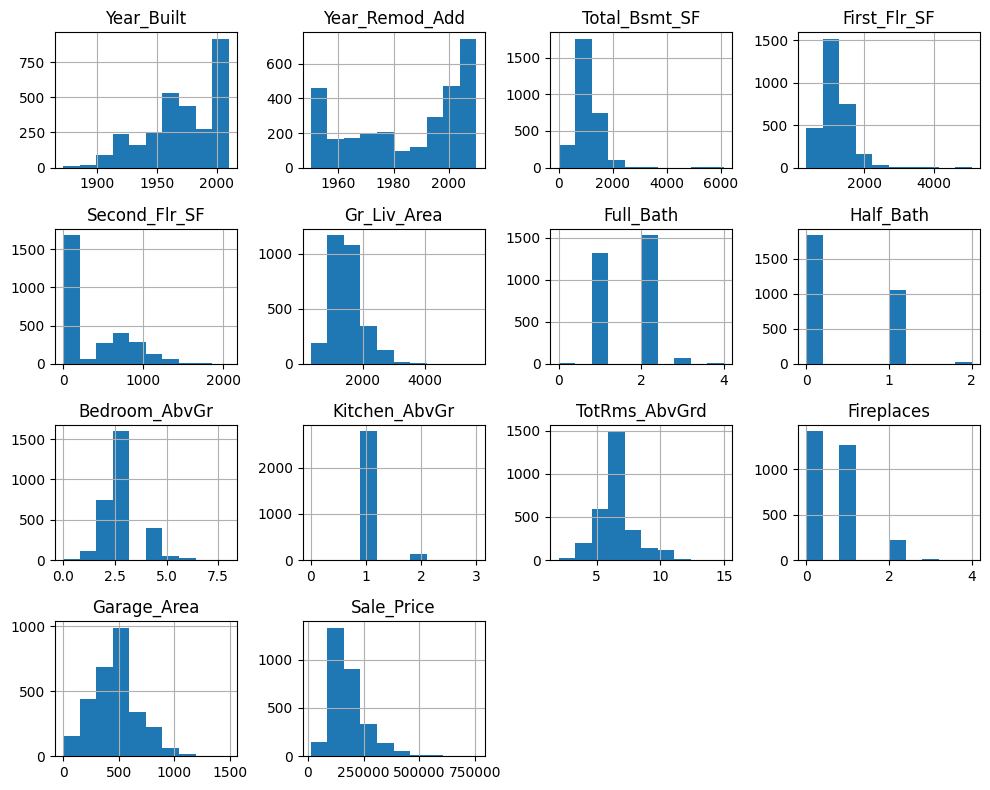

In [6]:
# Explore the data with visualisations such as histograms and correlation matrices

# Histograms
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

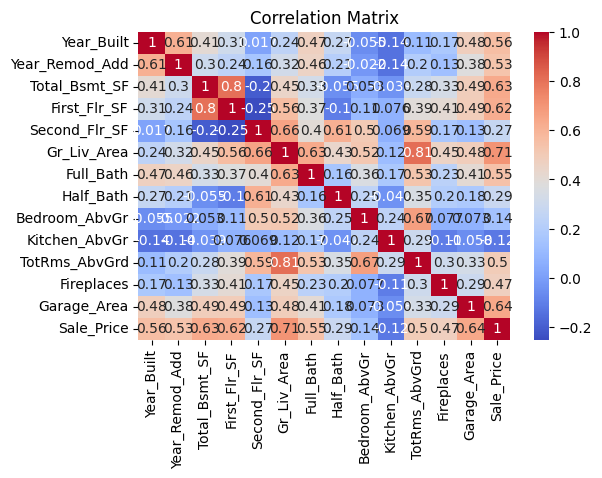

In [7]:
# Correlation matrix
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [8]:
# Summary statistics
df.describe()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1971.356314,1984.266553,1051.255631,1159.557679,335.455973,1499.690444,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,472.658362,180796.060068
std,30.245361,20.860286,440.968018,391.890885,428.395715,505.508887,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,215.187196,79886.692357
min,1872.000000,1950.000000,0.000000,334.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,12789.000000
25%,1954.000000,1965.000000,793.000000,876.250000,0.000000,1126.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,320.000000,129500.000000
50%,1973.000000,1993.000000,990.000000,1084.000000,0.000000,1442.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,480.000000,160000.000000
75%,2001.000000,2004.000000,1301.500000,1384.000000,703.750000,1742.750000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,576.000000,213500.000000
max,2010.000000,2010.000000,6110.000000,5095.000000,2065.000000,5642.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,1488.000000,755000.000000


In [9]:
# Split the independent variables from the dependent variable

X = df[['Gr_Liv_Area', 'Garage_Area']]
y = df['Sale_Price']

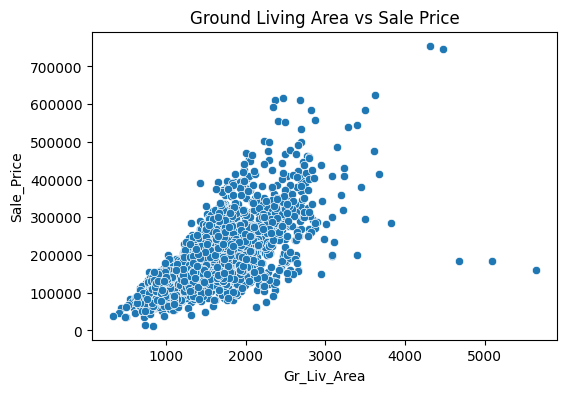

In [10]:
# Generate plots to explore relationships between variables

# Gr_Liv_Area vs Sale_Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='Gr_Liv_Area', y='Sale_Price', data=df)
plt.title("Ground Living Area vs Sale Price")
plt.show()

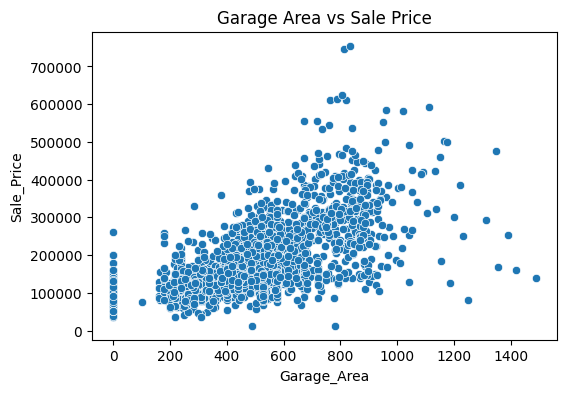

In [11]:
# Garage_Area vs Sale_Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='Garage_Area', y='Sale_Price', data=df)
plt.title("Garage Area vs Sale Price")
plt.show()

In [12]:
# Create a training and test set with a 75:25 split ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [13]:
# Build a multiple linear regression model

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# Print the trained model's intercept and coefficients

print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

Intercept: -5059.448195610428
       Feature  Coefficient
0  Gr_Liv_Area    78.692868
1  Garage_Area   141.145718


In [15]:
# Generate predictions for the test set

y_pred = model.predict(X_test)

# Display first few predictions
predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

predictions.head()

,Actual,Predicted
1357,161000,158224.094309
2367,116000,113256.675789
2822,196500,217552.819113
2126,123600,72846.491601
1544,126000,94782.712872


In [16]:
# Evaluate model performance

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 2634371879.6902103
Root Mean Squared Error (RMSE): 51326.13252223676


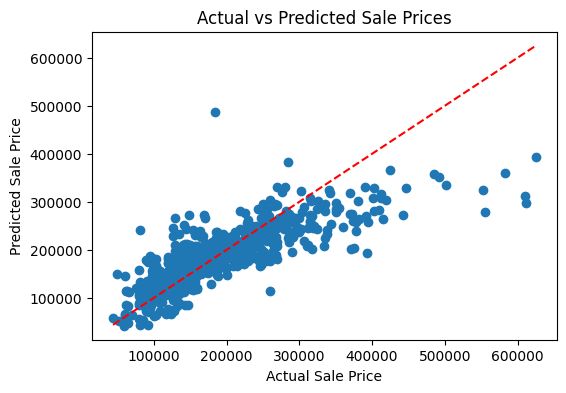

In [17]:
# Generate an error plot

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Prices")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

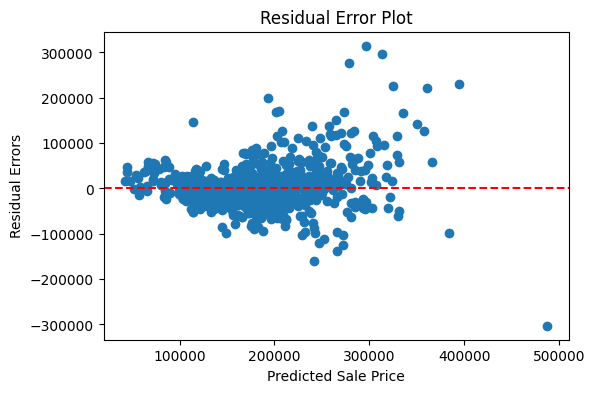

In [18]:
# Residual error plot

errors = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, errors)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")

plt.show()

In [19]:
# Print coefficients

print(coefficients)

       Feature  Coefficient
0  Gr_Liv_Area    78.692868
1  Garage_Area   141.145718


**Interpret coefficients in the context of the prediction:**
The coefficient for Gr_Liv_Area shows how much the sale price is expected to increase for every additional square foot of above-ground living area, while keeping garage area constant.

The coefficient for Garage_Area shows how much the sale price is expected to increase for every additional square foot of garage area, while keeping living area constant.

If the coefficients are positive, this indicates that larger living areas and larger garages generally increase the sale price of the house.

The intercept represents the predicted sale price when both Gr_Liv_Area and Garage_Area are zero, although this situation is not practically meaningful for real houses.

In [20]:
# Calculate median values

median_gr_liv_area = df['Gr_Liv_Area'].median()

median_garage_area = df['Garage_Area'].median()

print("Median Gr_Liv_Area:", median_gr_liv_area)

print("Median Garage_Area:", median_garage_area)

# Create dataframe using median values

median_house = pd.DataFrame({
    'Gr_Liv_Area': [median_gr_liv_area],
    'Garage_Area': [median_garage_area]
})

# Predict sale price

median_prediction = model.predict(median_house)

print("Predicted Sale Price:", median_prediction[0])

Median Gr_Liv_Area: 1442.0
Median Garage_Area: 480.0
Predicted Sale Price: 176165.61260651087


# Interpretation Using Median Value Prediction

The median values for `Gr_Liv_Area` and `Garage_Area` were used to estimate the predicted sale price of a typical house in the dataset.

The regression equation used for the prediction was:

Sale Price = β₀ + (β₁ × Gr_Liv_Area) + (β₂ × Garage_Area)

Where:

- β₀ represents the intercept
- β₁ represents the coefficient for `Gr_Liv_Area`
- β₂ represents the coefficient for `Garage_Area`

Using the median values for both predictor variables, the model generated a predicted sale price representing a house with average living area and garage area characteristics.

This prediction demonstrates how the intercept and coefficients work together mathematically to estimate house sale prices based on the selected independent variables.

The results suggest that increases in above-ground living area and garage area contribute positively to the predicted sale price of a house.

**Summarise findings**
The exploratory data analysis showed positive relationships between Gr_Liv_Area, Garage_Area, and Sale_Price. Houses with larger living areas and larger garages generally sold for higher prices.

The correlation matrix indicated that Gr_Liv_Area had a stronger correlation with sale price than Garage_Area, suggesting it is the more influential predictor.

The multiple linear regression model was successfully trained using the selected independent variables. The model produced reasonable predictions for house sale prices, and the RMSE value provided an indication of the model’s prediction accuracy.

The residual plots showed whether prediction errors were randomly distributed around zero, which helps determine whether the linear regression assumptions were reasonably satisfied.

Overall, the model demonstrated that living area and garage area are useful predictors of house sale prices in the Ames housing dataset.